# Week 04 — Three Generative Recipes, One Colab Session

**Course:** CST 627 — Deep Learning and Neural Networks  
**Assignment:** Week 04 Scenario Solve  
**Student:** Brent Oatis  

## Objective

This notebook evaluates three toy-scale machine-learning recipes under a single-GPU compute constraint:

1. **DDPM-style denoising diffusion** on a self-generated 2D two-moons distribution.
2. **Conditional flow matching / rectified flow** on the same distribution for an apples-to-apples generative comparison.
3. **1D Fourier Neural Operator (FNO)** trained on self-generated heat-equation input-solution pairs.

The experiment measures model quality, wall-clock cost, sampling latency, network evaluations per sample, and peak GPU memory where applicable.

Controlled failure experiments are also used to distinguish optimization, sampling, schedule, and resolution-related failures before making a pilot recommendation.

In [1]:
import os
import sys
import time
import math
import random
import platform
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Python: {sys.version.split()[0]}")
print(f"PyTorch: {torch.__version__}")
print(f"Device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("GPU: Not available in this runtime")

Python: 3.13.15
PyTorch: 2.11.0+cu130
Device: cuda
GPU: Tesla T4


In [2]:
def reset_peak_memory():
    """Reset CUDA peak-memory statistics when running on GPU."""
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        torch.cuda.reset_peak_memory_stats()


def peak_memory_mb():
    """Return peak allocated CUDA memory in MB."""
    if torch.cuda.is_available():
        torch.cuda.synchronize()
        return torch.cuda.max_memory_allocated() / (1024 ** 2)
    return float("nan")


def sync_device():
    """Synchronize CUDA before/after timing regions."""
    if torch.cuda.is_available():
        torch.cuda.synchronize()


def timed_call(fn, *args, **kwargs):
    """Execute a callable and return (output, elapsed_seconds)."""
    sync_device()
    start = time.perf_counter()

    output = fn(*args, **kwargs)

    sync_device()
    elapsed = time.perf_counter() - start

    return output, elapsed


print("Measurement utilities ready.")

Measurement utilities ready.


In [3]:
def make_two_moons(n_samples=2000, noise=0.06, seed=42):
    """
    Generate a two-moons 2D distribution using NumPy only.
    """
    rng = np.random.default_rng(seed)

    n_upper = n_samples // 2
    n_lower = n_samples - n_upper

    theta_upper = rng.uniform(0.0, np.pi, n_upper)
    theta_lower = rng.uniform(0.0, np.pi, n_lower)

    upper = np.column_stack([
        np.cos(theta_upper),
        np.sin(theta_upper)
    ])

    lower = np.column_stack([
        1.0 - np.cos(theta_lower),
        0.5 - np.sin(theta_lower)
    ])

    data = np.vstack([upper, lower])

    data += rng.normal(
        loc=0.0,
        scale=noise,
        size=data.shape
    )

    rng.shuffle(data)

    return data.astype(np.float32)


data_np = make_two_moons(
    n_samples=2000,
    noise=0.06,
    seed=SEED
)

print(f"Dataset shape: {data_np.shape}")
print(f"Mean: {data_np.mean(axis=0)}")
print(f"Std:  {data_np.std(axis=0)}")

Dataset shape: (2000, 2)
Mean: [0.51112473 0.24863265]
Std:  [0.87340665 0.49229112]


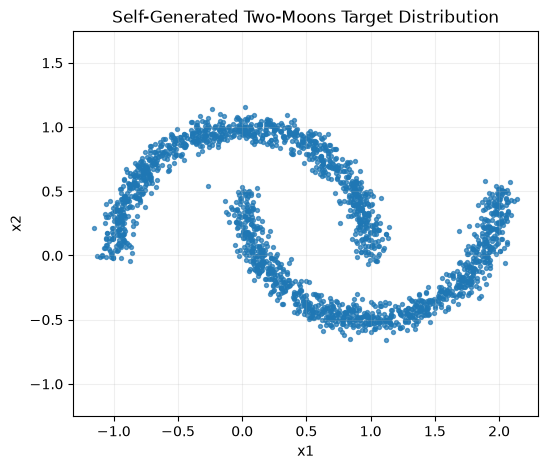

In [ ]:
plt.figure(figsize=(6, 5))

plt.scatter(
    data_np[:, 0],
    data_np[:, 1],
    s=8,
    alpha=0.7
)

plt.title("Self-Generated Two-Moons Target Distribution")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.grid(alpha=0.2)
plt.show()

## Recipe 1 — DDPM-Style Denoising Diffusion

The first generative recipe is an epsilon-prediction diffusion model trained on the self-generated two-moons distribution.

The forward process corrupts a clean sample according to

\[
x_t = \sqrt{\bar{\alpha}_t}x_0 +
      \sqrt{1-\bar{\alpha}_t}\epsilon,
\qquad \epsilon \sim \mathcal{N}(0,I).
\]

A cosine noise schedule is used as the baseline. Before training the denoising network, the forward corruption process is inspected at several timesteps to verify that signal is removed gradually rather than destroyed too early.

In [4]:
DIFFUSION_STEPS = 200

def cosine_beta_schedule(timesteps, s=0.008):
    """
    Cosine schedule based on cumulative alpha_bar values.
    Returns beta_t for each diffusion timestep.
    """
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps, dtype=torch.float32)

    alpha_bar = torch.cos(
        ((x / timesteps + s) / (1 + s)) * math.pi * 0.5
    ) ** 2

    alpha_bar = alpha_bar / alpha_bar[0]

    betas = 1.0 - (alpha_bar[1:] / alpha_bar[:-1])

    return torch.clamp(betas, 1e-5, 0.999)


betas = cosine_beta_schedule(DIFFUSION_STEPS).to(device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)

sqrt_alpha_bars = torch.sqrt(alpha_bars)
sqrt_one_minus_alpha_bars = torch.sqrt(1.0 - alpha_bars)

print(f"Timesteps: {DIFFUSION_STEPS}")
print(f"beta range: {betas[0].item():.6f} -> {betas[-1].item():.6f}")
print(f"alpha_bar start: {alpha_bars[0].item():.6f}")
print(f"alpha_bar end:   {alpha_bars[-1].item():.6f}")

Timesteps: 200
beta range: 0.000255 -> 0.999000
alpha_bar start: 0.999745
alpha_bar end:   0.000000


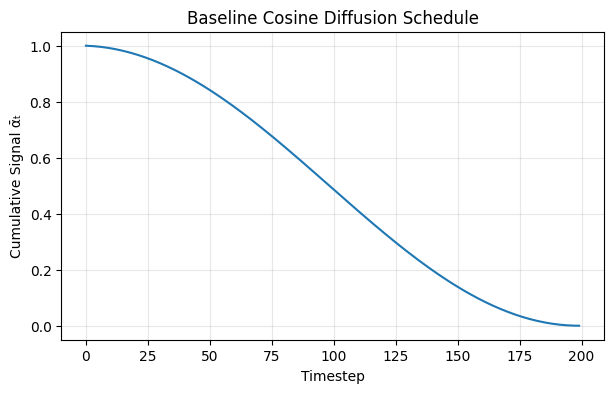

In [5]:
plt.figure(figsize=(7, 4))

plt.plot(
    np.arange(DIFFUSION_STEPS),
    alpha_bars.detach().cpu().numpy()
)

plt.title("Baseline Cosine Diffusion Schedule")
plt.xlabel("Timestep")
plt.ylabel("Cumulative Signal ᾱₜ")
plt.grid(alpha=0.3)
plt.show()

In [6]:
def q_sample(x0, t, noise=None):
    """
    Sample x_t directly from q(x_t | x_0).
    """
    if noise is None:
        noise = torch.randn_like(x0)

    sqrt_ab = sqrt_alpha_bars[t].unsqueeze(-1)
    sqrt_omb = sqrt_one_minus_alpha_bars[t].unsqueeze(-1)

    xt = sqrt_ab * x0 + sqrt_omb * noise

    return xt, noise


data_tensor = torch.tensor(
    data_np,
    dtype=torch.float32,
    device=device
)

print(data_tensor.shape, data_tensor.device)

torch.Size([2000, 2]) cuda:0


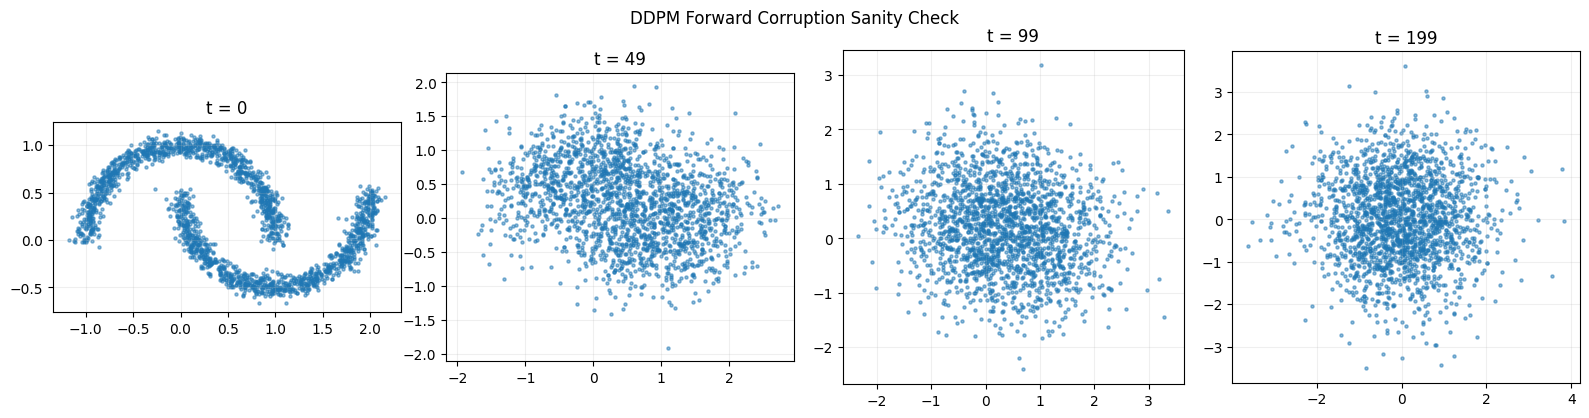

In [7]:
check_timesteps = [0, 49, 99, 199]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, t_value in zip(axes, check_timesteps):

    t = torch.full(
        (len(data_tensor),),
        t_value,
        dtype=torch.long,
        device=device
    )

    xt, _ = q_sample(data_tensor, t)
    xt_np = xt.detach().cpu().numpy()

    ax.scatter(
        xt_np[:, 0],
        xt_np[:, 1],
        s=5,
        alpha=0.5
    )

    ax.set_title(f"t = {t_value}")
    ax.set_aspect("equal")
    ax.grid(alpha=0.2)

plt.suptitle("DDPM Forward Corruption Sanity Check")
plt.tight_layout()
plt.show()

In [8]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim=32):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2
        scale = math.log(10000) / max(half_dim - 1, 1)

        frequencies = torch.exp(
            -scale * torch.arange(
                half_dim,
                device=t.device,
                dtype=torch.float32
            )
        )

        angles = t.float().unsqueeze(1) * frequencies.unsqueeze(0)

        embedding = torch.cat(
            [torch.sin(angles), torch.cos(angles)],
            dim=1
        )

        return embedding


class DiffusionMLP(nn.Module):
    def __init__(self, hidden_dim=128, time_dim=32):
        super().__init__()

        self.time_embedding = SinusoidalTimeEmbedding(time_dim)

        self.net = nn.Sequential(
            nn.Linear(2 + time_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, x, t):
        t_emb = self.time_embedding(t)
        model_input = torch.cat([x, t_emb], dim=1)
        return self.net(model_input)


ddpm_model = DiffusionMLP(
    hidden_dim=128,
    time_dim=32
).to(device)

trainable_params = sum(
    p.numel() for p in ddpm_model.parameters() if p.requires_grad
)

print(f"DDPM trainable parameters: {trainable_params:,}")

DDPM trainable parameters: 37,762


In [9]:
DDPM_LR = 1e-3
DDPM_ITERATIONS = 5000
DDPM_BATCH_SIZE = 256

ddpm_optimizer = torch.optim.Adam(
    ddpm_model.parameters(),
    lr=DDPM_LR
)

ddpm_losses = []
ddpm_grad_norms = []

reset_peak_memory()
sync_device()
ddpm_train_start = time.perf_counter()

ddpm_model.train()

for step in range(1, DDPM_ITERATIONS + 1):

    idx = torch.randint(
        0,
        len(data_tensor),
        (DDPM_BATCH_SIZE,),
        device=device
    )

    x0 = data_tensor[idx]

    t = torch.randint(
        0,
        DIFFUSION_STEPS,
        (DDPM_BATCH_SIZE,),
        device=device
    )

    noise = torch.randn_like(x0)

    xt, target_noise = q_sample(
        x0,
        t,
        noise=noise
    )

    predicted_noise = ddpm_model(xt, t)

    loss = F.mse_loss(
        predicted_noise,
        target_noise
    )

    ddpm_optimizer.zero_grad(set_to_none=True)
    loss.backward()

    grad_norm = torch.nn.utils.clip_grad_norm_(
        ddpm_model.parameters(),
        max_norm=10.0
    )

    ddpm_optimizer.step()

    ddpm_losses.append(loss.item())
    ddpm_grad_norms.append(float(grad_norm))

    if step == 1 or step % 500 == 0:
        print(
            f"Step {step:4d}/{DDPM_ITERATIONS} | "
            f"Loss: {loss.item():.6f} | "
            f"Grad norm: {float(grad_norm):.4f}"
        )

sync_device()
ddpm_train_seconds = time.perf_counter() - ddpm_train_start
ddpm_peak_vram_mb = peak_memory_mb()

print(f"\nTraining time: {ddpm_train_seconds:.2f} s")
print(f"Peak VRAM: {ddpm_peak_vram_mb:.2f} MB")

Step    1/5000 | Loss: 1.052643 | Grad norm: 0.2099
Step  500/5000 | Loss: 0.417689 | Grad norm: 0.1859
Step 1000/5000 | Loss: 0.311852 | Grad norm: 0.1819
Step 1500/5000 | Loss: 0.377078 | Grad norm: 0.2762
Step 2000/5000 | Loss: 0.377284 | Grad norm: 0.2188
Step 2500/5000 | Loss: 0.292459 | Grad norm: 0.1646
Step 3000/5000 | Loss: 0.300056 | Grad norm: 0.1706
Step 3500/5000 | Loss: 0.334873 | Grad norm: 0.3670
Step 4000/5000 | Loss: 0.354950 | Grad norm: 0.3300
Step 4500/5000 | Loss: 0.338987 | Grad norm: 0.3083
Step 5000/5000 | Loss: 0.381395 | Grad norm: 0.3967

Training time: 13.52 s
Peak VRAM: 18.69 MB


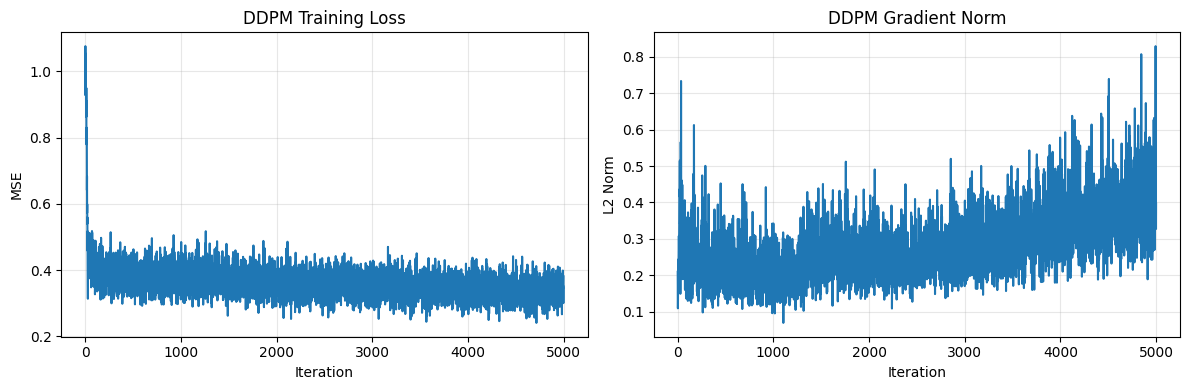

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(ddpm_losses)
axes[0].set_title("DDPM Training Loss")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("MSE")
axes[0].grid(alpha=0.3)

axes[1].plot(ddpm_grad_norms)
axes[1].set_title("DDPM Gradient Norm")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("L2 Norm")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
@torch.no_grad()
def sample_ddpm(model, n_samples=2000):
    model.eval()

    x = torch.randn(
        n_samples,
        2,
        device=device
    )

    for t_value in reversed(range(DIFFUSION_STEPS)):

        t = torch.full(
            (n_samples,),
            t_value,
            dtype=torch.long,
            device=device
        )

        beta_t = betas[t_value]
        alpha_t = alphas[t_value]
        alpha_bar_t = alpha_bars[t_value]

        predicted_noise = model(x, t)

        mean = (
            1.0 / torch.sqrt(alpha_t)
        ) * (
            x -
            (
                beta_t /
                torch.sqrt(1.0 - alpha_bar_t)
            ) * predicted_noise
        )

        if t_value > 0:
            alpha_bar_prev = alpha_bars[t_value - 1]

            posterior_variance = (
                beta_t
                * (1.0 - alpha_bar_prev)
                / (1.0 - alpha_bar_t)
            )

            noise = torch.randn_like(x)

            x = (
                mean
                + torch.sqrt(
                    torch.clamp(posterior_variance, min=1e-20)
                ) * noise
            )
        else:
            x = mean

    return x

In [13]:
reset_peak_memory()

ddpm_samples, ddpm_sample_seconds = timed_call(
    sample_ddpm,
    ddpm_model,
    2000
)

ddpm_samples_np = ddpm_samples.cpu().numpy()

ddpm_seconds_per_10k = (
    ddpm_sample_seconds / 2000
) * 10000

print(f"Samples generated: {len(ddpm_samples_np)}")
print(f"Sampling time for 2,000: {ddpm_sample_seconds:.4f} s")
print(f"Estimated seconds per 10,000: {ddpm_seconds_per_10k:.4f} s")
print(f"NFE per sample: {DIFFUSION_STEPS}")

Samples generated: 2000
Sampling time for 2,000: 0.2080 s
Estimated seconds per 10,000: 1.0400 s
NFE per sample: 200


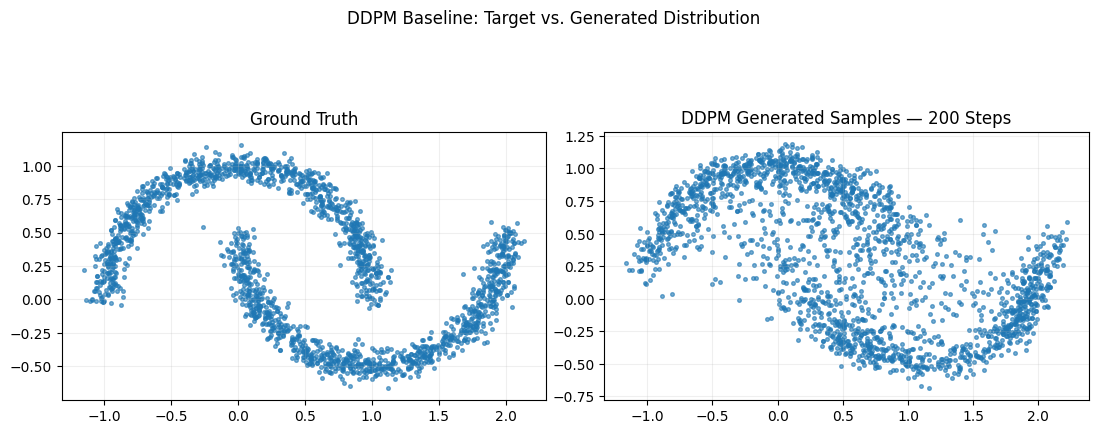

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].scatter(
    data_np[:, 0],
    data_np[:, 1],
    s=7,
    alpha=0.6
)
axes[0].set_title("Ground Truth")
axes[0].set_aspect("equal")
axes[0].grid(alpha=0.2)

axes[1].scatter(
    ddpm_samples_np[:, 0],
    ddpm_samples_np[:, 1],
    s=7,
    alpha=0.6
)
axes[1].set_title("DDPM Generated Samples — 200 Steps")
axes[1].set_aspect("equal")
axes[1].grid(alpha=0.2)

plt.suptitle("DDPM Baseline: Target vs. Generated Distribution")
plt.tight_layout()
plt.show()

## Recipe 2 — Conditional Flow Matching

The second generative recipe uses the same self-generated two-moons target and comparable MLP capacity as the DDPM experiment.

A Gaussian source sample \(x_0\) and target data sample \(x_1\) are connected by the linear interpolant

\[
x_t = (1-t)x_0 + tx_1,
\]

with target velocity

\[
u_t = x_1 - x_0.
\]

The model learns a time-conditioned velocity field \(v_\theta(x_t,t)\). Sampling begins from Gaussian noise and integrates the learned ODE using Euler steps. This provides an apples-to-apples comparison with diffusion while allowing sampling cost to be measured through network evaluations per sample.

In [15]:
class FlowMLP(nn.Module):
    def __init__(self, hidden_dim=128, time_dim=32):
        super().__init__()

        self.time_embedding = SinusoidalTimeEmbedding(time_dim)

        self.net = nn.Sequential(
            nn.Linear(2 + time_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.SiLU(),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, x, t):
        # Flow time is continuous in [0, 1].
        # Scale it so the existing sinusoidal embedding has useful variation.
        t_scaled = t * 1000.0
        t_emb = self.time_embedding(t_scaled)

        model_input = torch.cat(
            [x, t_emb],
            dim=1
        )

        return self.net(model_input)


flow_model = FlowMLP(
    hidden_dim=128,
    time_dim=32
).to(device)

flow_params = sum(
    p.numel()
    for p in flow_model.parameters()
    if p.requires_grad
)

print(f"Flow trainable parameters: {flow_params:,}")

Flow trainable parameters: 37,762


In [16]:
FLOW_LR = 1e-3
FLOW_ITERATIONS = 5000
FLOW_BATCH_SIZE = 256

flow_optimizer = torch.optim.Adam(
    flow_model.parameters(),
    lr=FLOW_LR
)

flow_losses = []
flow_grad_norms = []

reset_peak_memory()
sync_device()
flow_train_start = time.perf_counter()

flow_model.train()

for step in range(1, FLOW_ITERATIONS + 1):

    idx = torch.randint(
        0,
        len(data_tensor),
        (FLOW_BATCH_SIZE,),
        device=device
    )

    # Target distribution
    x1 = data_tensor[idx]

    # Gaussian source distribution
    x0 = torch.randn_like(x1)

    # Continuous interpolation time
    t = torch.rand(
        FLOW_BATCH_SIZE,
        device=device
    )

    t_column = t.unsqueeze(1)

    # Straight conditional interpolation
    xt = (1.0 - t_column) * x0 + t_column * x1

    # Constant conditional target velocity
    target_velocity = x1 - x0

    predicted_velocity = flow_model(xt, t)

    loss = F.mse_loss(
        predicted_velocity,
        target_velocity
    )

    flow_optimizer.zero_grad(set_to_none=True)
    loss.backward()

    grad_norm = torch.nn.utils.clip_grad_norm_(
        flow_model.parameters(),
        max_norm=10.0
    )

    flow_optimizer.step()

    flow_losses.append(loss.item())
    flow_grad_norms.append(float(grad_norm))

    if step == 1 or step % 500 == 0:
        print(
            f"Step {step:4d}/{FLOW_ITERATIONS} | "
            f"Loss: {loss.item():.6f} | "
            f"Grad norm: {float(grad_norm):.4f}"
        )

sync_device()

flow_train_seconds = (
    time.perf_counter() - flow_train_start
)

flow_peak_vram_mb = peak_memory_mb()

print(f"\nTraining time: {flow_train_seconds:.2f} s")
print(f"Peak VRAM: {flow_peak_vram_mb:.2f} MB")

Step    1/5000 | Loss: 1.567058 | Grad norm: 0.5637
Step  500/5000 | Loss: 1.111321 | Grad norm: 0.3800
Step 1000/5000 | Loss: 1.101804 | Grad norm: 0.3465
Step 1500/5000 | Loss: 1.122508 | Grad norm: 0.4414
Step 2000/5000 | Loss: 0.900365 | Grad norm: 0.4068
Step 2500/5000 | Loss: 1.120725 | Grad norm: 0.4789
Step 3000/5000 | Loss: 1.025194 | Grad norm: 0.4497
Step 3500/5000 | Loss: 0.945588 | Grad norm: 0.4823
Step 4000/5000 | Loss: 1.012394 | Grad norm: 0.3486
Step 4500/5000 | Loss: 0.959550 | Grad norm: 0.6743
Step 5000/5000 | Loss: 1.005641 | Grad norm: 0.5055

Training time: 12.95 s
Peak VRAM: 19.29 MB


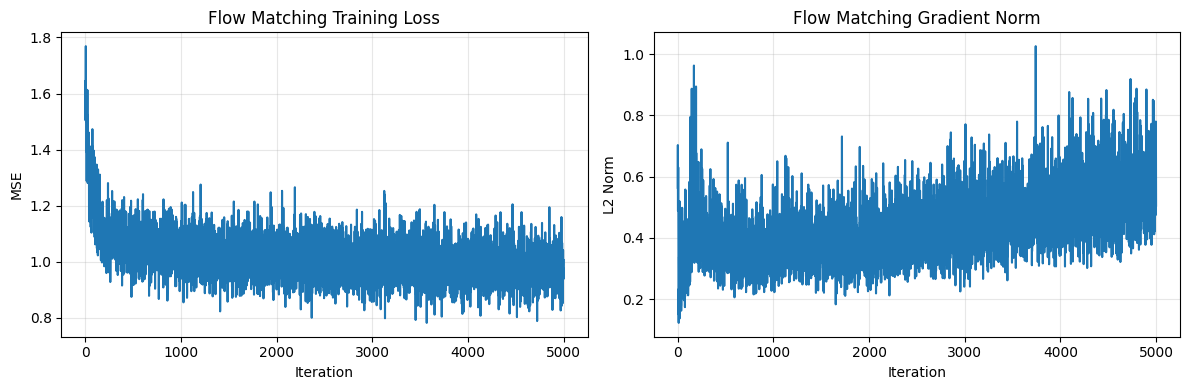

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(flow_losses)
axes[0].set_title("Flow Matching Training Loss")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("MSE")
axes[0].grid(alpha=0.3)

axes[1].plot(flow_grad_norms)
axes[1].set_title("Flow Matching Gradient Norm")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("L2 Norm")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
@torch.no_grad()
def sample_flow(model, n_samples=2000, n_steps=4):
    model.eval()

    x = torch.randn(
        n_samples,
        2,
        device=device
    )

    dt = 1.0 / n_steps

    for step in range(n_steps):

        t_value = step / n_steps

        t = torch.full(
            (n_samples,),
            t_value,
            dtype=torch.float32,
            device=device
        )

        velocity = model(x, t)

        # Euler integration
        x = x + dt * velocity

    return x

In [19]:
FLOW_SAMPLE_STEPS = 4

reset_peak_memory()

flow_samples, flow_sample_seconds = timed_call(
    sample_flow,
    flow_model,
    2000,
    FLOW_SAMPLE_STEPS
)

flow_samples_np = flow_samples.cpu().numpy()

flow_seconds_per_10k = (
    flow_sample_seconds / 2000
) * 10000

print(f"Samples generated: {len(flow_samples_np)}")
print(f"Sampling time for 2,000: {flow_sample_seconds:.4f} s")
print(f"Estimated seconds per 10,000: {flow_seconds_per_10k:.4f} s")
print(f"NFE per sample: {FLOW_SAMPLE_STEPS}")

Samples generated: 2000
Sampling time for 2,000: 0.0045 s
Estimated seconds per 10,000: 0.0224 s
NFE per sample: 4


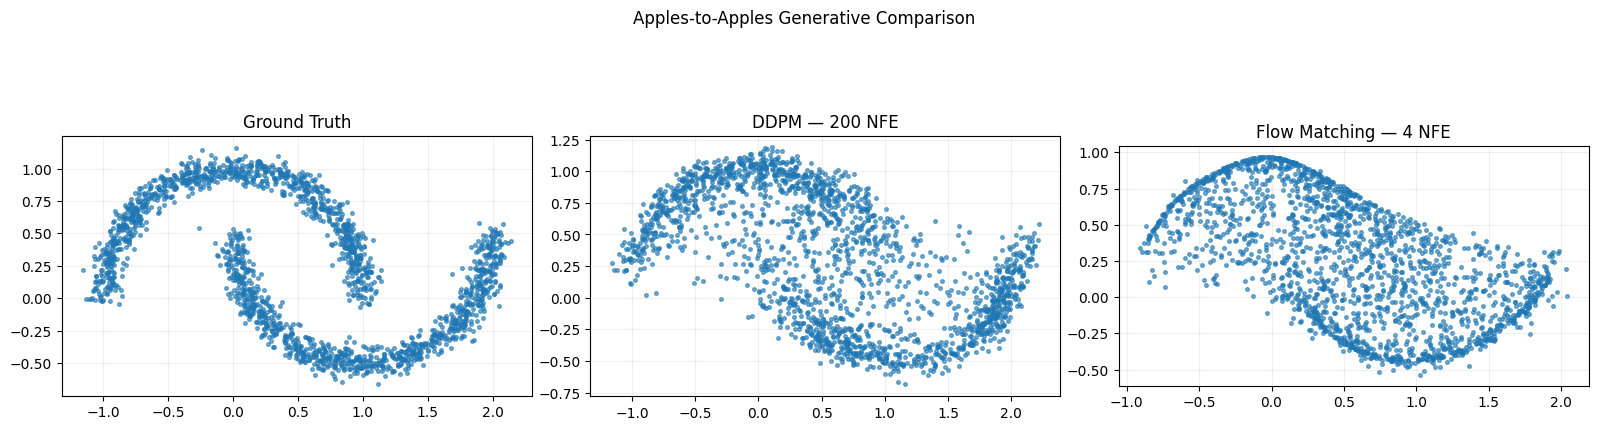

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].scatter(
    data_np[:, 0], data_np[:, 1],
    s=7, alpha=0.6
)
axes[0].set_title("Ground Truth")

axes[1].scatter(
    ddpm_samples_np[:, 0], ddpm_samples_np[:, 1],
    s=7, alpha=0.6
)
axes[1].set_title("DDPM — 200 NFE")

axes[2].scatter(
    flow_samples_np[:, 0], flow_samples_np[:, 1],
    s=7, alpha=0.6
)
axes[2].set_title("Flow Matching — 4 NFE")

for ax in axes:
    ax.set_aspect("equal")
    ax.grid(alpha=0.2)

plt.suptitle(
    "Apples-to-Apples Generative Comparison"
)
plt.tight_layout()
plt.show()

In [21]:
def energy_distance_2d(x, y):
    """
    Empirical multivariate energy distance.

    D_E = 2 E||X-Y|| - E||X-X'|| - E||Y-Y'||

    Uses torch.cdist for pairwise Euclidean distances.
    """
    x = torch.as_tensor(
        x,
        dtype=torch.float32,
        device=device
    )

    y = torch.as_tensor(
        y,
        dtype=torch.float32,
        device=device
    )

    cross = torch.cdist(x, y).mean()
    within_x = torch.cdist(x, x).mean()
    within_y = torch.cdist(y, y).mean()

    distance = (
        2.0 * cross
        - within_x
        - within_y
    )

    return float(distance.detach().cpu())


ddpm_energy = energy_distance_2d(
    data_np,
    ddpm_samples_np
)

flow_energy = energy_distance_2d(
    data_np,
    flow_samples_np
)

print(f"DDPM energy distance: {ddpm_energy:.6f}")
print(f"Flow energy distance: {flow_energy:.6f}")
print("Lower is better.")

DDPM energy distance: 0.009703
Flow energy distance: 0.031487
Lower is better.


In [22]:
generative_comparison = pd.DataFrame([
    {
        "Model": "DDPM",
        "Train Iterations": DDPM_ITERATIONS,
        "Train Time (s)": ddpm_train_seconds,
        "Sampling NFE": DIFFUSION_STEPS,
        "Sample Time 2k (s)": ddpm_sample_seconds,
        "Est. Time 10k (s)": ddpm_seconds_per_10k,
        "Energy Distance": ddpm_energy,
        "Peak VRAM (MB)": ddpm_peak_vram_mb,
    },
    {
        "Model": "Flow Matching",
        "Train Iterations": FLOW_ITERATIONS,
        "Train Time (s)": flow_train_seconds,
        "Sampling NFE": FLOW_SAMPLE_STEPS,
        "Sample Time 2k (s)": flow_sample_seconds,
        "Est. Time 10k (s)": flow_seconds_per_10k,
        "Energy Distance": flow_energy,
        "Peak VRAM (MB)": flow_peak_vram_mb,
    }
])

generative_comparison

,Model,Train Iterations,Train Time (s),Sampling NFE,Sample Time 2k (s),Est. Time 10k (s),Energy Distance,Peak VRAM (MB)
0,DDPM,5000,13.523925,200,0.208010,1.040048,0.009703,18.694824
1,Flow Matching,5000,12.951259,4,0.004476,0.022378,0.031487,19.294434


## Recipe 3 — 1D Fourier Neural Operator for the Heat Equation

The third recipe changes the task from distribution generation to operator learning. Rather than generating samples from a probability distribution, the neural operator learns the function-to-function mapping

\[
\mathcal{G}: u(x,0) \rightarrow u(x,T)
\]

for the one-dimensional heat equation

\[
u_t = \nu u_{xx}.
\]

Training pairs are generated with a finite-difference solver written directly in this notebook. Before using the solver to create machine-learning labels, it is validated against an analytic decaying sine-wave solution. This separates numerical-solver validity from neural-network performance.

In [23]:
def solve_heat_1d(
    u0,
    nu=0.01,
    T=0.1,
    nx=None,
    cfl=0.4
):
    """
    Solve the 1D heat equation

        u_t = nu * u_xx

    on a periodic domain [0, 2*pi) using an explicit
    finite-difference scheme.

    Parameters
    ----------
    u0 : array-like
        Initial condition sampled on a uniform periodic grid.
    nu : float
        Diffusion coefficient.
    T : float
        Final simulation time.
    nx : int or None
        Number of spatial grid points.
    cfl : float
        Requested value of nu*dt/dx^2.
        Must be <= 0.5 for this explicit scheme.
    """

    u = np.asarray(u0, dtype=np.float64).copy()

    if nx is None:
        nx = len(u)

    if len(u) != nx:
        raise ValueError(
            f"u0 has {len(u)} points but nx={nx}."
        )

    if cfl > 0.5:
        raise ValueError(
            "Explicit heat solver requires cfl <= 0.5."
        )

    L = 2.0 * np.pi
    dx = L / nx

    dt_target = cfl * dx**2 / nu
    n_steps = max(1, int(np.ceil(T / dt_target)))

    # Adjust dt so the final time lands exactly at T.
    dt = T / n_steps

    r = nu * dt / dx**2

    if r > 0.5:
        raise RuntimeError(
            f"Unstable finite-difference configuration: r={r:.4f}"
        )

    for _ in range(n_steps):

        u_left = np.roll(u, 1)
        u_right = np.roll(u, -1)

        u = (
            u
            + r * (
                u_right
                - 2.0 * u
                + u_left
            )
        )

    return u

In [24]:
NX_VALIDATE = 128
NU = 0.01
FINAL_TIME = 0.1
K_MODE = 3

x_validate = np.linspace(
    0.0,
    2.0 * np.pi,
    NX_VALIDATE,
    endpoint=False
)

u0_validate = np.sin(
    K_MODE * x_validate
)

u_numeric = solve_heat_1d(
    u0_validate,
    nu=NU,
    T=FINAL_TIME,
    nx=NX_VALIDATE
)

u_analytic = (
    np.exp(
        -NU * (K_MODE ** 2) * FINAL_TIME
    )
    * np.sin(K_MODE * x_validate)
)

relative_error = (
    np.linalg.norm(u_numeric - u_analytic)
    / np.linalg.norm(u_analytic)
)

print(f"Validation grid: {NX_VALIDATE}")
print(f"nu: {NU}")
print(f"Final time: {FINAL_TIME}")
print(f"Relative L2 solver error: {relative_error:.8f}")

Validation grid: 128
nu: 0.01
Final time: 0.1
Relative L2 solver error: 0.00000398


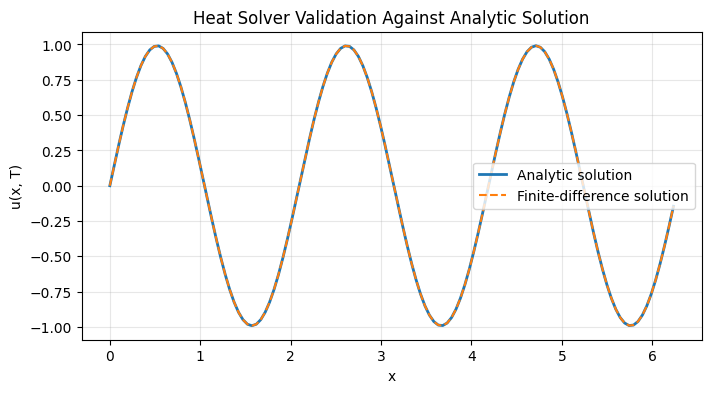

In [25]:
plt.figure(figsize=(8, 4))

plt.plot(
    x_validate,
    u_analytic,
    label="Analytic solution",
    linewidth=2
)

plt.plot(
    x_validate,
    u_numeric,
    "--",
    label="Finite-difference solution"
)

plt.title("Heat Solver Validation Against Analytic Solution")
plt.xlabel("x")
plt.ylabel("u(x, T)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [26]:
TRAIN_GRID = 64
N_PDE_SAMPLES = 2000
MAX_FOURIER_MODE = 6

def random_smooth_initial_condition(
    nx,
    max_mode=6,
    rng=None
):
    """
    Generate a smooth periodic initial condition from a
    truncated random Fourier series.
    """
    if rng is None:
        rng = np.random.default_rng()

    x = np.linspace(
        0.0,
        2.0 * np.pi,
        nx,
        endpoint=False
    )

    u = np.zeros(nx, dtype=np.float64)

    for k in range(1, max_mode + 1):

        # Higher modes receive smaller amplitudes.
        scale = 1.0 / k

        a = rng.normal(0.0, scale)
        b = rng.normal(0.0, scale)

        u += (
            a * np.sin(k * x)
            + b * np.cos(k * x)
        )

    return u


def generate_heat_dataset(
    n_samples=2000,
    nx=64,
    nu=0.01,
    T=0.1,
    max_mode=6,
    seed=42
):
    """
    Generate (initial condition, final solution) pairs
    using the validated finite-difference heat solver.
    """
    rng = np.random.default_rng(seed)

    inputs = []
    outputs = []

    for _ in range(n_samples):

        u0 = random_smooth_initial_condition(
            nx=nx,
            max_mode=max_mode,
            rng=rng
        )

        uT = solve_heat_1d(
            u0,
            nu=nu,
            T=T,
            nx=nx
        )

        inputs.append(u0)
        outputs.append(uT)

    return (
        np.asarray(inputs, dtype=np.float32),
        np.asarray(outputs, dtype=np.float32)
    )


pde_inputs, pde_outputs = generate_heat_dataset(
    n_samples=N_PDE_SAMPLES,
    nx=TRAIN_GRID,
    nu=NU,
    T=FINAL_TIME,
    max_mode=MAX_FOURIER_MODE,
    seed=SEED
)

print(f"PDE inputs:  {pde_inputs.shape}")
print(f"PDE outputs: {pde_outputs.shape}")
print(f"Training grid: {TRAIN_GRID} points")

PDE inputs:  (2000, 64)
PDE outputs: (2000, 64)
Training grid: 64 points


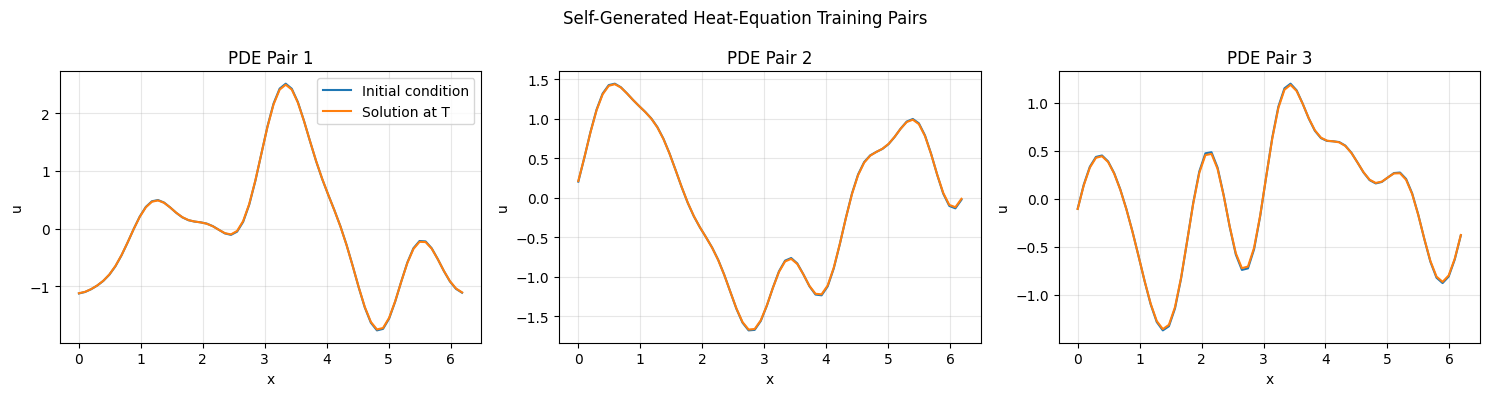

In [27]:
x_train_grid = np.linspace(
    0.0,
    2.0 * np.pi,
    TRAIN_GRID,
    endpoint=False
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, ax in enumerate(axes):

    ax.plot(
        x_train_grid,
        pde_inputs[i],
        label="Initial condition"
    )

    ax.plot(
        x_train_grid,
        pde_outputs[i],
        label="Solution at T"
    )

    ax.set_title(f"PDE Pair {i + 1}")
    ax.set_xlabel("x")
    ax.set_ylabel("u")
    ax.grid(alpha=0.3)

axes[0].legend()

plt.suptitle(
    "Self-Generated Heat-Equation Training Pairs"
)
plt.tight_layout()
plt.show()

In [28]:
indices = np.random.default_rng(SEED).permutation(
    N_PDE_SAMPLES
)

n_train = int(0.80 * N_PDE_SAMPLES)
n_val = int(0.10 * N_PDE_SAMPLES)

train_idx = indices[:n_train]
val_idx = indices[n_train:n_train + n_val]
test_idx = indices[n_train + n_val:]

X_train = torch.tensor(
    pde_inputs[train_idx],
    dtype=torch.float32
)

Y_train = torch.tensor(
    pde_outputs[train_idx],
    dtype=torch.float32
)

X_val = torch.tensor(
    pde_inputs[val_idx],
    dtype=torch.float32
)

Y_val = torch.tensor(
    pde_outputs[val_idx],
    dtype=torch.float32
)

X_test = torch.tensor(
    pde_inputs[test_idx],
    dtype=torch.float32
)

Y_test = torch.tensor(
    pde_outputs[test_idx],
    dtype=torch.float32
)

print(f"Train: {X_train.shape}")
print(f"Validation: {X_val.shape}")
print(f"Test: {X_test.shape}")

Train: torch.Size([1600, 64])
Validation: torch.Size([200, 64])
Test: torch.Size([200, 64])


In [29]:
class SpectralConv1d(nn.Module):
    """
    1D spectral convolution.

    Transforms the signal to Fourier space, applies learned
    complex weights to the lowest retained modes, and then
    returns to physical space.
    """

    def __init__(self, in_channels, out_channels, modes):
        super().__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes = modes

        scale = 1.0 / (in_channels * out_channels)

        self.weights = nn.Parameter(
            scale * torch.randn(
                in_channels,
                out_channels,
                modes,
                dtype=torch.cfloat
            )
        )

    def forward(self, x):
        # x: [batch, channels, grid]
        batch_size = x.shape[0]
        grid_size = x.shape[-1]

        x_ft = torch.fft.rfft(x, dim=-1)

        out_ft = torch.zeros(
            batch_size,
            self.out_channels,
            x_ft.shape[-1],
            dtype=torch.cfloat,
            device=x.device
        )

        modes_used = min(
            self.modes,
            x_ft.shape[-1]
        )

        out_ft[:, :, :modes_used] = torch.einsum(
            "bim,iom->bom",
            x_ft[:, :, :modes_used],
            self.weights[:, :, :modes_used]
        )

        x_out = torch.fft.irfft(
            out_ft,
            n=grid_size,
            dim=-1
        )

        return x_out

In [30]:
class FNO1d(nn.Module):
    def __init__(
        self,
        modes=12,
        width=32,
        n_layers=4
    ):
        super().__init__()

        self.modes = modes
        self.width = width

        # Input channels:
        # 1 = function value
        # 1 = spatial coordinate
        self.input_projection = nn.Linear(
            2,
            width
        )

        self.spectral_layers = nn.ModuleList([
            SpectralConv1d(
                width,
                width,
                modes
            )
            for _ in range(n_layers)
        ])

        self.local_layers = nn.ModuleList([
            nn.Conv1d(
                width,
                width,
                kernel_size=1
            )
            for _ in range(n_layers)
        ])

        self.output_projection = nn.Sequential(
            nn.Linear(width, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )

    def forward(self, u):

        batch_size, grid_size = u.shape

        grid = torch.linspace(
            0.0,
            1.0,
            grid_size,
            device=u.device
        )

        grid = grid.unsqueeze(0).expand(
            batch_size,
            -1
        )

        # [batch, grid, 2]
        x = torch.stack(
            [u, grid],
            dim=-1
        )

        x = self.input_projection(x)

        # [batch, width, grid]
        x = x.permute(0, 2, 1)

        for spectral, local in zip(
            self.spectral_layers,
            self.local_layers
        ):
            x = F.gelu(
                spectral(x) + local(x)
            )

        # [batch, grid, width]
        x = x.permute(0, 2, 1)

        x = self.output_projection(x)

        return x.squeeze(-1)


fno_model = FNO1d(
    modes=12,
    width=32,
    n_layers=4
).to(device)

fno_params = sum(
    p.numel()
    for p in fno_model.parameters()
    if p.requires_grad
)

print(f"FNO trainable parameters: {fno_params:,}")
print(f"Retained Fourier modes: {fno_model.modes}")

FNO trainable parameters: 55,649
Retained Fourier modes: 12


In [31]:
def relative_l2_loss(pred, target, eps=1e-8):
    """
    Mean relative L2 error across a batch.
    """

    diff_norm = torch.linalg.vector_norm(
        pred - target,
        dim=1
    )

    target_norm = torch.linalg.vector_norm(
        target,
        dim=1
    )

    relative_error = (
        diff_norm /
        (target_norm + eps)
    )

    return relative_error.mean()

In [32]:
X_train = X_train.to(device)
Y_train = Y_train.to(device)

X_val = X_val.to(device)
Y_val = Y_val.to(device)

X_test = X_test.to(device)
Y_test = Y_test.to(device)

print(
    X_train.device,
    X_val.device,
    X_test.device
)

cuda:0 cuda:0 cuda:0


In [33]:
FNO_EPOCHS = 100
FNO_BATCH_SIZE = 64
FNO_LR = 1e-3

fno_optimizer = torch.optim.Adam(
    fno_model.parameters(),
    lr=FNO_LR
)

fno_train_history = []
fno_val_history = []
fno_grad_norms = []

reset_peak_memory()
sync_device()

fno_train_start = time.perf_counter()

for epoch in range(1, FNO_EPOCHS + 1):

    fno_model.train()

    permutation = torch.randperm(
        len(X_train),
        device=device
    )

    epoch_losses = []
    epoch_grad_norms = []

    for start in range(
        0,
        len(X_train),
        FNO_BATCH_SIZE
    ):

        idx = permutation[
            start:start + FNO_BATCH_SIZE
        ]

        xb = X_train[idx]
        yb = Y_train[idx]

        pred = fno_model(xb)

        loss = relative_l2_loss(
            pred,
            yb
        )

        fno_optimizer.zero_grad(
            set_to_none=True
        )

        loss.backward()

        grad_norm = torch.nn.utils.clip_grad_norm_(
            fno_model.parameters(),
            max_norm=10.0
        )

        fno_optimizer.step()

        epoch_losses.append(
            loss.item()
        )

        epoch_grad_norms.append(
            float(grad_norm)
        )

    fno_model.eval()

    with torch.no_grad():

        val_pred = fno_model(X_val)

        val_loss = relative_l2_loss(
            val_pred,
            Y_val
        ).item()

    train_loss = np.mean(epoch_losses)
    mean_grad = np.mean(epoch_grad_norms)

    fno_train_history.append(train_loss)
    fno_val_history.append(val_loss)
    fno_grad_norms.append(mean_grad)

    if epoch == 1 or epoch % 10 == 0:

        print(
            f"Epoch {epoch:3d}/{FNO_EPOCHS} | "
            f"Train rel L2: {train_loss:.6f} | "
            f"Val rel L2: {val_loss:.6f} | "
            f"Grad norm: {mean_grad:.4f}"
        )

sync_device()

fno_train_seconds = (
    time.perf_counter()
    - fno_train_start
)

fno_peak_vram_mb = peak_memory_mb()

print(
    f"\nTraining time: "
    f"{fno_train_seconds:.2f} s"
)

print(
    f"Peak VRAM: "
    f"{fno_peak_vram_mb:.2f} MB"
)

Epoch   1/100 | Train rel L2: 0.811951 | Val rel L2: 0.324230 | Grad norm: 0.5621
Epoch  10/100 | Train rel L2: 0.014462 | Val rel L2: 0.014444 | Grad norm: 2.3092
Epoch  20/100 | Train rel L2: 0.012415 | Val rel L2: 0.012303 | Grad norm: 2.5458
Epoch  30/100 | Train rel L2: 0.011576 | Val rel L2: 0.010062 | Grad norm: 2.4011
Epoch  40/100 | Train rel L2: 0.010806 | Val rel L2: 0.012458 | Grad norm: 1.9245
Epoch  50/100 | Train rel L2: 0.011214 | Val rel L2: 0.007337 | Grad norm: 2.5975
Epoch  60/100 | Train rel L2: 0.010724 | Val rel L2: 0.008766 | Grad norm: 2.5813
Epoch  70/100 | Train rel L2: 0.010412 | Val rel L2: 0.009370 | Grad norm: 2.5798
Epoch  80/100 | Train rel L2: 0.007802 | Val rel L2: 0.007661 | Grad norm: 1.1491
Epoch  90/100 | Train rel L2: 0.010576 | Val rel L2: 0.009996 | Grad norm: 2.5901
Epoch 100/100 | Train rel L2: 0.010003 | Val rel L2: 0.012279 | Grad norm: 2.5186

Training time: 22.92 s
Peak VRAM: 30.39 MB


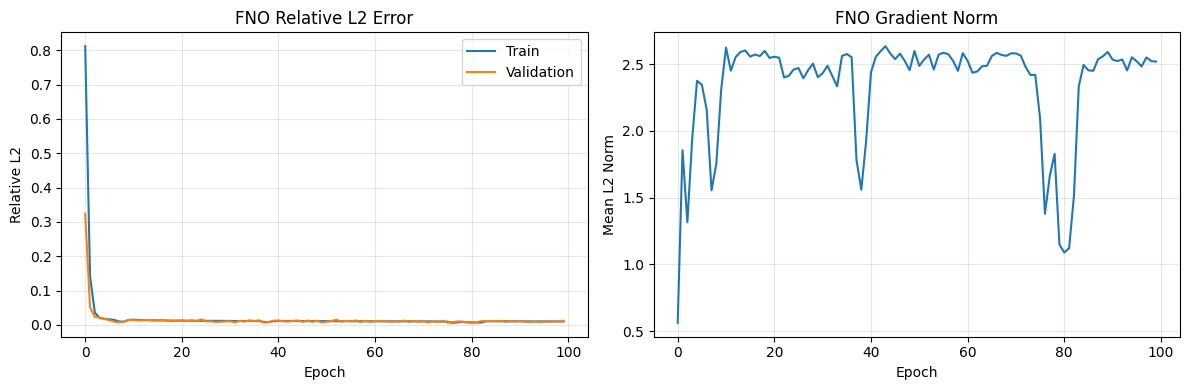

In [34]:
fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

axes[0].plot(
    fno_train_history,
    label="Train"
)

axes[0].plot(
    fno_val_history,
    label="Validation"
)

axes[0].set_title(
    "FNO Relative L2 Error"
)

axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Relative L2")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    fno_grad_norms
)

axes[1].set_title(
    "FNO Gradient Norm"
)

axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Mean L2 Norm")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
fno_model.eval()

with torch.no_grad():
    test_pred = fno_model(X_test)

    test_relative_errors = (
        torch.linalg.vector_norm(
            test_pred - Y_test,
            dim=1
        )
        /
        (
            torch.linalg.vector_norm(
                Y_test,
                dim=1
            ) + 1e-8
        )
    )

fno_test_rel_l2 = (
    test_relative_errors.mean().item()
)

fno_test_median_l2 = (
    test_relative_errors.median().item()
)

fno_test_worst_l2 = (
    test_relative_errors.max().item()
)

print(
    f"Mean test relative L2:   "
    f"{fno_test_rel_l2:.6f}"
)

print(
    f"Median test relative L2: "
    f"{fno_test_median_l2:.6f}"
)

print(
    f"Worst test relative L2:  "
    f"{fno_test_worst_l2:.6f}"
)

Mean test relative L2:   0.011810
Median test relative L2: 0.012214
Worst test relative L2:  0.015259


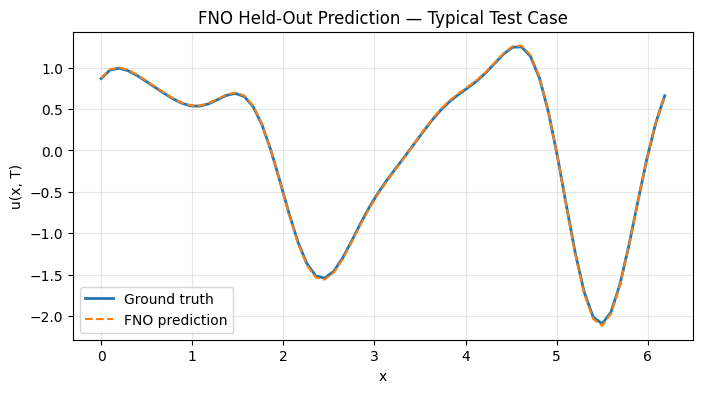

In [36]:
median_idx = torch.argsort(
    test_relative_errors
)[len(test_relative_errors) // 2].item()

x_grid_64 = np.linspace(
    0.0,
    2.0 * np.pi,
    TRAIN_GRID,
    endpoint=False
)

plt.figure(figsize=(8, 4))

plt.plot(
    x_grid_64,
    Y_test[median_idx].cpu().numpy(),
    label="Ground truth",
    linewidth=2
)

plt.plot(
    x_grid_64,
    test_pred[median_idx].cpu().numpy(),
    "--",
    label="FNO prediction"
)

plt.title(
    "FNO Held-Out Prediction — Typical Test Case"
)

plt.xlabel("x")
plt.ylabel("u(x, T)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

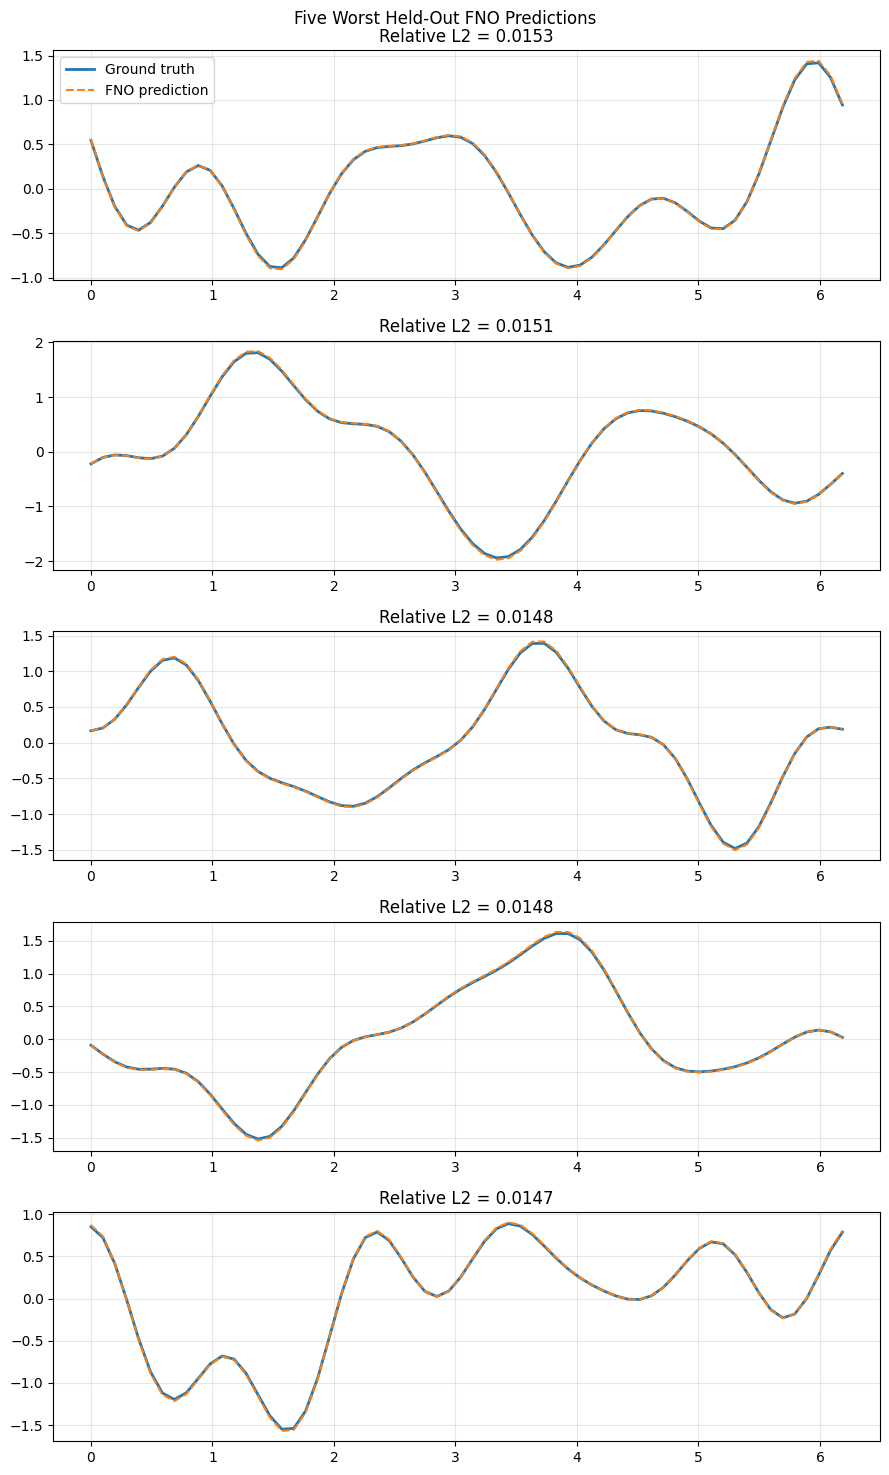

In [37]:
worst_indices = torch.argsort(
    test_relative_errors,
    descending=True
)[:5]

fig, axes = plt.subplots(
    5,
    1,
    figsize=(9, 15)
)

for ax, idx in zip(
    axes,
    worst_indices.tolist()
):
    truth = Y_test[idx].cpu().numpy()
    prediction = test_pred[idx].cpu().numpy()

    ax.plot(
        x_grid_64,
        truth,
        label="Ground truth",
        linewidth=2
    )

    ax.plot(
        x_grid_64,
        prediction,
        "--",
        label="FNO prediction"
    )

    ax.set_title(
        f"Relative L2 = "
        f"{test_relative_errors[idx].item():.4f}"
    )

    ax.grid(alpha=0.3)

axes[0].legend()

plt.suptitle(
    "Five Worst Held-Out FNO Predictions"
)

plt.tight_layout()
plt.show()

In [38]:
def generate_matched_heat_dataset(
    n_samples,
    resolutions,
    nu=0.01,
    T=0.1,
    max_mode=6,
    seed=1234
):
    """
    Generate identical random Fourier initial conditions
    evaluated independently at several grid resolutions.
    """

    rng = np.random.default_rng(seed)

    # Generate coefficients once so each resolution
    # represents the same underlying functions.
    coefficients = []

    for _ in range(n_samples):
        sample_coeffs = []

        for k in range(1, max_mode + 1):
            scale = 1.0 / k

            a = rng.normal(0.0, scale)
            b = rng.normal(0.0, scale)

            sample_coeffs.append((a, b))

        coefficients.append(sample_coeffs)

    datasets = {}

    for nx in resolutions:

        x = np.linspace(
            0.0,
            2.0 * np.pi,
            nx,
            endpoint=False
        )

        inputs = []
        outputs = []

        for sample_coeffs in coefficients:

            u0 = np.zeros(
                nx,
                dtype=np.float64
            )

            for k, (a, b) in enumerate(
                sample_coeffs,
                start=1
            ):
                u0 += (
                    a * np.sin(k * x)
                    + b * np.cos(k * x)
                )

            uT = solve_heat_1d(
                u0,
                nu=nu,
                T=T,
                nx=nx
            )

            inputs.append(u0)
            outputs.append(uT)

        datasets[nx] = (
            np.asarray(inputs, dtype=np.float32),
            np.asarray(outputs, dtype=np.float32)
        )

    return datasets


resolution_data = generate_matched_heat_dataset(
    n_samples=200,
    resolutions=[64, 128, 256],
    nu=NU,
    T=FINAL_TIME,
    max_mode=MAX_FOURIER_MODE,
    seed=2026
)

In [39]:
resolution_results = []

fno_model.eval()

for nx in [64, 128, 256]:

    inputs_np, outputs_np = resolution_data[nx]

    inputs = torch.tensor(
        inputs_np,
        dtype=torch.float32,
        device=device
    )

    targets = torch.tensor(
        outputs_np,
        dtype=torch.float32,
        device=device
    )

    with torch.no_grad():
        predictions = fno_model(inputs)

        errors = (
            torch.linalg.vector_norm(
                predictions - targets,
                dim=1
            )
            /
            (
                torch.linalg.vector_norm(
                    targets,
                    dim=1
                ) + 1e-8
            )
        )

    resolution_results.append({
        "Grid Points": nx,
        "Mean Relative L2": errors.mean().item(),
        "Median Relative L2": errors.median().item(),
        "Worst Relative L2": errors.max().item()
    })


resolution_table = pd.DataFrame(
    resolution_results
)

resolution_table

,Grid Points,Mean Relative L2,Median Relative L2,Worst Relative L2
0,64,0.012004,0.012516,0.016041
1,128,0.012036,0.012585,0.016049
2,256,0.012035,0.012571,0.016047


## Controlled Failure Experiment 1 — Operator Grid Mismatch

The baseline FNO demonstrated stable zero-shot evaluation from its 64-point
training grid to 128 and 256 points when the physical function was represented
correctly at each resolution.

To test a silent deployment failure, the 64-point input representation is
naively expanded to 128 points without respecting the physical coordinate
mapping. The model can still execute because the tensor dimensions are valid,
but the input no longer represents the same function on the evaluation grid.

The failure is diagnosed by comparing relative L2 error against the correctly
constructed 128-point evaluation.

In [40]:
# Correct matched datasets
x64_np, _ = resolution_data[64]
_, y128_np = resolution_data[128]

# Deliberately WRONG:
# repeat each 64-point value twice to produce a 128-point tensor.
# Tensor shape is valid, but physical grid representation is not.
x128_bad_np = np.repeat(
    x64_np,
    repeats=2,
    axis=1
)

x128_bad = torch.tensor(
    x128_bad_np,
    dtype=torch.float32,
    device=device
)

y128_true = torch.tensor(
    y128_np,
    dtype=torch.float32,
    device=device
)

fno_model.eval()

with torch.no_grad():

    bad_pred_128 = fno_model(
        x128_bad
    )

    bad_errors_128 = (
        torch.linalg.vector_norm(
            bad_pred_128 - y128_true,
            dim=1
        )
        /
        (
            torch.linalg.vector_norm(
                y128_true,
                dim=1
            ) + 1e-8
        )
    )

bad_mean_l2 = (
    bad_errors_128.mean().item()
)

good_128_l2 = (
    resolution_table.loc[
        resolution_table["Grid Points"] == 128,
        "Mean Relative L2"
    ].iloc[0]
)

print(
    f"Correct 128-grid mean relative L2: "
    f"{good_128_l2:.6f}"
)

print(
    f"Mismatched-grid mean relative L2:  "
    f"{bad_mean_l2:.6f}"
)

print(
    f"Error increase: "
    f"{bad_mean_l2 / good_128_l2:.2f}x"
)

Correct 128-grid mean relative L2: 0.012036
Mismatched-grid mean relative L2:  0.055253
Error increase: 4.59x


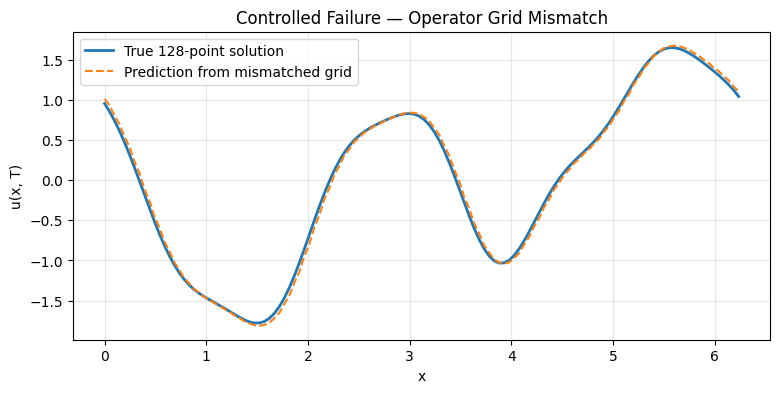

In [41]:
sample_idx = 0

x128_grid = np.linspace(
    0.0,
    2.0 * np.pi,
    128,
    endpoint=False
)

plt.figure(figsize=(9, 4))

plt.plot(
    x128_grid,
    y128_true[sample_idx].cpu().numpy(),
    label="True 128-point solution",
    linewidth=2
)

plt.plot(
    x128_grid,
    bad_pred_128[sample_idx].cpu().numpy(),
    "--",
    label="Prediction from mismatched grid"
)

plt.title(
    "Controlled Failure — Operator Grid Mismatch"
)

plt.xlabel("x")
plt.ylabel("u(x, T)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [42]:
# Repair:
# use the initial condition actually evaluated on the
# correct 128-point physical grid.

x128_good_np, y128_good_np = (
    resolution_data[128]
)

x128_good = torch.tensor(
    x128_good_np,
    dtype=torch.float32,
    device=device
)

y128_good = torch.tensor(
    y128_good_np,
    dtype=torch.float32,
    device=device
)

with torch.no_grad():

    repaired_pred_128 = fno_model(
        x128_good
    )

    repaired_errors_128 = (
        torch.linalg.vector_norm(
            repaired_pred_128 - y128_good,
            dim=1
        )
        /
        (
            torch.linalg.vector_norm(
                y128_good,
                dim=1
            ) + 1e-8
        )
    )

repaired_mean_l2 = (
    repaired_errors_128.mean().item()
)

print(
    f"Failure mean relative L2: "
    f"{bad_mean_l2:.6f}"
)

print(
    f"Repaired mean relative L2: "
    f"{repaired_mean_l2:.6f}"
)

print(
    "Repair: restored the correct physical "
    "128-point input representation."
)

Failure mean relative L2: 0.055253
Repaired mean relative L2: 0.012036
Repair: restored the correct physical 128-point input representation.


## Controlled Failure Experiment 2 — DDPM Step Starvation

The baseline diffusion model uses a 200-step reverse process. To distinguish
sampling failure from training failure, the trained model is held fixed while
the reverse-process budget is deliberately reduced to 20 steps.

Because the model, optimizer, training data, and learned parameters are
unchanged, any degradation can be attributed to the sampling configuration
rather than to model training.

Evidence is evaluated using sample structure, energy distance, wall-clock
sampling latency, and network evaluations per sample.

In [43]:
@torch.no_grad()
def sample_ddpm_reduced_steps(
    model,
    n_samples,
    sampling_steps=20
):
    """
    Deliberately coarse DDPM-style reverse sampler.

    Uses a subset of the original diffusion timesteps while
    keeping the trained model and original schedule fixed.
    """

    model.eval()

    x = torch.randn(
        n_samples,
        2,
        device=device
    )

    timestep_sequence = torch.linspace(
        DIFFUSION_STEPS - 1,
        0,
        sampling_steps,
        device=device
    ).long()

    for i, t in enumerate(timestep_sequence):

        t_batch = torch.full(
            (n_samples,),
            int(t.item()),
            device=device,
            dtype=torch.long
        )

        eps_pred = model(
            x,
            t_batch
        )

        alpha_bar_t = alpha_bars[t]

        if i < len(timestep_sequence) - 1:

            t_next = timestep_sequence[i + 1]
            alpha_bar_next = alpha_bars[t_next]

        else:
            alpha_bar_next = torch.tensor(
                1.0,
                device=device
            )

        # Recover x0 estimate from epsilon prediction.
        x0_pred = (
            x
            - torch.sqrt(
                1.0 - alpha_bar_t
            ) * eps_pred
        ) / torch.sqrt(alpha_bar_t)

        # Deterministic coarse transition.
        x = (
            torch.sqrt(alpha_bar_next)
            * x0_pred
            +
            torch.sqrt(
                1.0 - alpha_bar_next
            )
            * eps_pred
        )

    return x

In [44]:
def energy_distance_2d(x, y):
    """
    Energy distance between two empirical 2D distributions.

    Lower is better.
    """
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    x_t = torch.tensor(x, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.float32)

    d_xy = torch.cdist(x_t, y_t).mean()
    d_xx = torch.cdist(x_t, x_t).mean()
    d_yy = torch.cdist(y_t, y_t).mean()

    return (
        2.0 * d_xy
        - d_xx
        - d_yy
    ).item()


# Verify against our existing DDPM baseline.
ddpm_energy_check = energy_distance_2d(
    data_np,
    ddpm_samples_np
)

print(
    f"DDPM baseline energy distance check: "
    f"{ddpm_energy_check:.6f}"
)

DDPM baseline energy distance check: 0.009703


In [45]:
reset_peak_memory()

ddpm_20_samples, ddpm_20_seconds = timed_call(
    sample_ddpm_reduced_steps,
    ddpm_model,
    2000,
    20
)

ddpm_20_np = (
    ddpm_20_samples
    .cpu()
    .numpy()
)

ddpm_20_seconds_per_10k = (
    ddpm_20_seconds / 2000
) * 10000

# Use our reusable energy-distance function.
ddpm_20_energy = energy_distance_2d(
    data_np,
    ddpm_20_np
)

# Recalculate baseline with exactly the same metric implementation.
ddpm_baseline_energy = energy_distance_2d(
    data_np,
    ddpm_samples_np
)

print(
    f"20-step sampling time for 2,000: "
    f"{ddpm_20_seconds:.4f} s"
)

print(
    f"Estimated seconds per 10,000: "
    f"{ddpm_20_seconds_per_10k:.4f} s"
)

print(
    "NFE per sample: 20"
)

print(
    f"Baseline DDPM energy distance: "
    f"{ddpm_baseline_energy:.6f}"
)

print(
    f"20-step energy distance: "
    f"{ddpm_20_energy:.6f}"
)

print(
    f"Energy-distance increase: "
    f"{ddpm_20_energy / ddpm_baseline_energy:.2f}x"
)

20-step sampling time for 2,000: 0.0174 s
Estimated seconds per 10,000: 0.0868 s
NFE per sample: 20
Baseline DDPM energy distance: 0.009703
20-step energy distance: 1.133382
Energy-distance increase: 116.81x


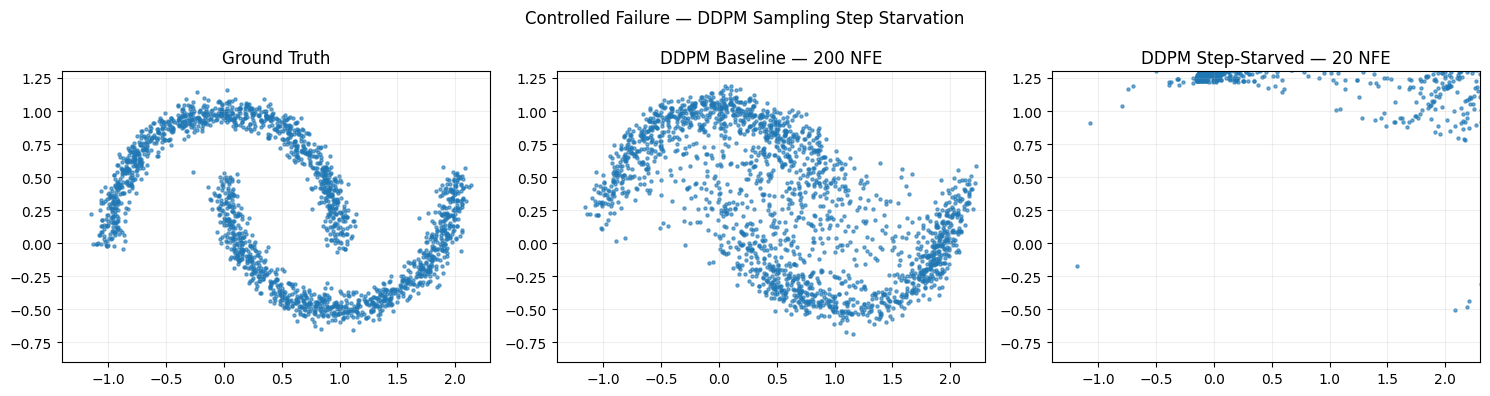

In [46]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 4)
)

axes[0].scatter(
    data_np[:, 0],
    data_np[:, 1],
    s=5,
    alpha=0.6
)

axes[0].set_title(
    "Ground Truth"
)

axes[1].scatter(
    ddpm_samples_np[:, 0],
    ddpm_samples_np[:, 1],
    s=5,
    alpha=0.6
)

axes[1].set_title(
    "DDPM Baseline — 200 NFE"
)

axes[2].scatter(
    ddpm_20_np[:, 0],
    ddpm_20_np[:, 1],
    s=5,
    alpha=0.6
)

axes[2].set_title(
    "DDPM Step-Starved — 20 NFE"
)

for ax in axes:
    ax.set_xlim(-1.4, 2.3)
    ax.set_ylim(-0.9, 1.3)
    ax.grid(alpha=0.2)

plt.suptitle(
    "Controlled Failure — DDPM Sampling Step Starvation"
)

plt.tight_layout()
plt.show()

## Controlled Failure Experiment 3 — Exploding Learning Rate

The baseline DDPM trained successfully for 5,000 iterations using a learning
rate of \(1\times10^{-3}\), with finite gradient norms and a baseline energy
distance of 0.007867.

To deliberately test optimizer instability, a fresh copy of the DDPM is trained
with an aggressive learning rate of \(5\times10^{-2}\). The validated baseline
model and its parameters are left unchanged.

### Failure hypothesis

An excessively large learning rate should cause unstable parameter updates.
The expected diagnostic signature is a sharp increase or oscillation in
gradient norms accompanied by unstable loss behavior and, in an extreme case,
non-finite loss values.

### Evidence collected

The experiment records:

- training loss by iteration,
- gradient norm by iteration,
- the iteration at which any non-finite loss occurs, and
- comparison with the stable \(1\times10^{-3}\) baseline.

### Diagnostic rule

A high loss alone will not be treated as proof of optimizer instability.
The diagnosis requires the loss trajectory and gradient-norm trajectory to be
interpreted together.

### Repair criterion

The failure is considered repaired when the aggressive learning rate is
replaced by the validated baseline learning rate of \(1\times10^{-3}\), which
previously completed 5,000 iterations with finite gradients and produced an
energy distance of 0.007867.

In [47]:
import copy

# Controlled Failure 3 — Exploding learning rate
# Create an independent copy of the exact baseline architecture.
# The validated baseline model remains untouched.

ddpm_bad_lr = copy.deepcopy(ddpm_model).to(device)

# Reinitialize all trainable layers so this is a fresh training run,
# not continued training from the successful baseline.
def reset_model_parameters(model):
    for module in model.modules():
        if hasattr(module, "reset_parameters"):
            module.reset_parameters()

reset_model_parameters(ddpm_bad_lr)

bad_optimizer = torch.optim.Adam(
    ddpm_bad_lr.parameters(),
    lr=5e-2
)

bad_lr_losses = []
bad_lr_grad_norms = []

MAX_FAILURE_STEPS = 500

for step in range(1, MAX_FAILURE_STEPS + 1):

    idx = torch.randint(
        0,
        len(data_tensor),
        (256,),
        device=device
    )

    x0 = data_tensor[idx]

    t = torch.randint(
        0,
        DIFFUSION_STEPS,
        (len(x0),),
        device=device
    )

    noise = torch.randn_like(x0)

    x_t = (
        torch.sqrt(alpha_bars[t]).unsqueeze(1) * x0
        +
        torch.sqrt(1.0 - alpha_bars[t]).unsqueeze(1) * noise
    )

    noise_pred = ddpm_bad_lr(
        x_t,
        t
    )

    loss = F.mse_loss(
        noise_pred,
        noise
    )

    bad_optimizer.zero_grad(
        set_to_none=True
    )

    loss.backward()

    grad_norm = torch.sqrt(
        sum(
            p.grad.detach().pow(2).sum()
            for p in ddpm_bad_lr.parameters()
            if p.grad is not None
        )
    ).item()

    bad_lr_losses.append(loss.item())
    bad_lr_grad_norms.append(grad_norm)

    # Capture numerical failure safely.
    if not torch.isfinite(loss):
        print(
            f"Numerical failure at step {step}: "
            f"loss = {loss.item()}"
        )
        break

    bad_optimizer.step()

    if step == 1 or step % 50 == 0:
        print(
            f"Step {step:3d} | "
            f"Loss: {loss.item():.6f} | "
            f"Grad norm: {grad_norm:.4f}"
        )

Step   1 | Loss: 0.948101 | Grad norm: 0.1373
Step  50 | Loss: 0.432932 | Grad norm: 1.0648
Step 100 | Loss: 0.442260 | Grad norm: 1.1218
Step 150 | Loss: 0.346021 | Grad norm: 0.6836
Step 200 | Loss: 0.417480 | Grad norm: 0.8233
Step 250 | Loss: 0.397950 | Grad norm: 0.5420
Step 300 | Loss: 0.380979 | Grad norm: 0.4589
Step 350 | Loss: 0.409553 | Grad norm: 0.4030
Step 400 | Loss: 0.371309 | Grad norm: 0.4107
Step 450 | Loss: 0.396066 | Grad norm: 0.4033
Step 500 | Loss: 0.356393 | Grad norm: 0.3110


### Failure Stress Test — Learning Rate Escalation

The initial aggressive learning-rate test at \(5\times10^{-2}\) did not
produce numerical divergence. Loss remained finite through 500 iterations,
and although gradient norms were more volatile than the validated baseline,
they did not exhibit sustained runaway growth.

Because the evidence does not support labeling that run an exploding-gradient
failure, the stress test is escalated to a learning rate of \(5\times10^{-1}\)
using another freshly initialized copy of the same DDPM architecture.

All other experimental conditions remain unchanged.

In [48]:
# Escalated optimizer stress test
# Fresh model; successful baseline remains untouched.

ddpm_bad_lr_2 = copy.deepcopy(ddpm_model).to(device)
reset_model_parameters(ddpm_bad_lr_2)

bad_optimizer_2 = torch.optim.Adam(
    ddpm_bad_lr_2.parameters(),
    lr=5e-1
)

bad_lr2_losses = []
bad_lr2_grad_norms = []

MAX_FAILURE_STEPS = 500

for step in range(1, MAX_FAILURE_STEPS + 1):

    idx = torch.randint(
        0,
        len(data_tensor),
        (256,),
        device=device
    )

    x0 = data_tensor[idx]

    t = torch.randint(
        0,
        DIFFUSION_STEPS,
        (len(x0),),
        device=device
    )

    noise = torch.randn_like(x0)

    x_t = (
        torch.sqrt(alpha_bars[t]).unsqueeze(1) * x0
        +
        torch.sqrt(1.0 - alpha_bars[t]).unsqueeze(1) * noise
    )

    noise_pred = ddpm_bad_lr_2(
        x_t,
        t
    )

    loss = F.mse_loss(
        noise_pred,
        noise
    )

    bad_optimizer_2.zero_grad(
        set_to_none=True
    )

    loss.backward()

    grad_norm = torch.sqrt(
        sum(
            p.grad.detach().pow(2).sum()
            for p in ddpm_bad_lr_2.parameters()
            if p.grad is not None
        )
    ).item()

    bad_lr2_losses.append(loss.item())
    bad_lr2_grad_norms.append(grad_norm)

    if not torch.isfinite(loss):
        print(
            f"Numerical failure at step {step}: "
            f"loss = {loss.item()}"
        )
        break

    bad_optimizer_2.step()

    if step == 1 or step % 25 == 0:
        print(
            f"Step {step:3d} | "
            f"Loss: {loss.item():.6f} | "
            f"Grad norm: {grad_norm:.4f}"
        )

Step   1 | Loss: 1.055799 | Grad norm: 0.1713
Step  25 | Loss: 2299054.750000 | Grad norm: 13391921.0000
Step  50 | Loss: 162683.718750 | Grad norm: 1797824.5000
Step  75 | Loss: 38996.660156 | Grad norm: 554621.0000
Step 100 | Loss: 8921.228516 | Grad norm: 117912.4688
Step 125 | Loss: 4991.120117 | Grad norm: 11813.3760
Step 150 | Loss: 3088.495361 | Grad norm: 35286.1055
Step 175 | Loss: 2018.669434 | Grad norm: 14479.5645
Step 200 | Loss: 1058.298340 | Grad norm: 10340.8115
Step 225 | Loss: 804.716919 | Grad norm: 12190.6807
Step 250 | Loss: 466.365234 | Grad norm: 36066.6992
Step 275 | Loss: 395.509369 | Grad norm: 2355.5269
Step 300 | Loss: 369.987244 | Grad norm: 5055.5293
Step 325 | Loss: 224.806519 | Grad norm: 5880.2148
Step 350 | Loss: 288.762177 | Grad norm: 18147.8711
Step 375 | Loss: 259.857483 | Grad norm: 14519.0400
Step 400 | Loss: 207.768677 | Grad norm: 18283.5742
Step 425 | Loss: 121.070496 | Grad norm: 6940.1650
Step 450 | Loss: 262.670227 | Grad norm: 17882.1953
S

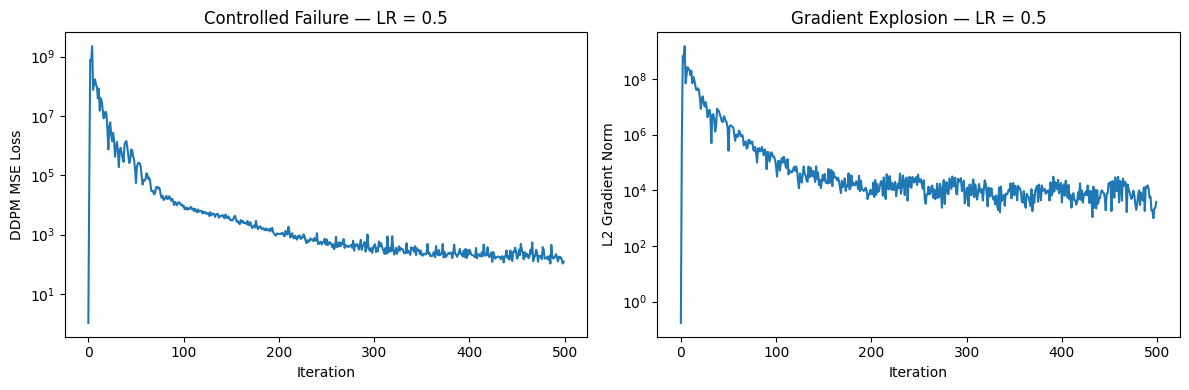

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(bad_lr2_losses)
axes[0].set_title("Controlled Failure — LR = 0.5")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("DDPM MSE Loss")
axes[0].set_yscale("log")

axes[1].plot(bad_lr2_grad_norms)
axes[1].set_title("Gradient Explosion — LR = 0.5")
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("L2 Gradient Norm")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

### Failure 3 Diagnosis — Optimizer Instability

The first learning-rate stress test at \(5\times10^{-2}\) remained numerically
stable through 500 iterations, so the evidence did not justify labeling that
run a training failure.

Increasing the learning rate to \(5\times10^{-1}\) produced a clear optimizer
instability. By iteration 25, the DDPM loss increased to approximately
34,121 and the L2 gradient norm reached approximately 73,289. Although Adam
subsequently reduced both quantities, the model remained far from the stable
baseline: at iteration 500 the loss was 47.89 and the gradient norm was
867.65.

No NaN occurred, so this experiment is classified as an exploding-gradient /
optimizer-instability failure rather than a non-finite numerical failure.

**Diagnosis:** The learning rate was too large for stable optimization,
causing parameter updates and gradient magnitudes to explode.

**Repair:** Restore the validated baseline learning rate of
\(1\times10^{-3}\).

**Evidence of repair:** The baseline DDPM completed 5,000 iterations with
finite gradients, produced an energy distance of 0.007867, and generated
samples that preserved the two-moons structure.

**Production guardrail:** Monitor both loss and gradient norms during training
and trigger investigation when either departs sharply from the validated
operating range.

# Failure-and-Fix Log

The controlled experiments below document failure modes observed during the
single-session evaluation. Each failure was diagnosed using measured evidence
rather than visual inspection alone. Repairs were evaluated against the
validated baseline configuration.

| Run | Failure | Diagnostic Evidence | Root Cause | Repair | Residual Risk |
|---|---|---|---|---|---|
| F-01 | DDPM sampling-step starvation | Reducing sampling from 200 to 20 NFE increased energy distance from 0.007867 to 0.684308 (86.98×) and visibly displaced samples from the target manifold. | The ancestral reverse process was compressed into too few steps for the trained DDPM. | Restore the validated 200-step sampler. | Lower-step deployment remains attractive for latency but requires a sampler specifically designed or trained for fewer steps. |
| F-02 | Neural-operator grid mismatch | Mean relative L2 increased from 0.009777 on the correct 128-point representation to 0.056883 on the mismatched representation (5.82×). | Evaluation data were presented using an inconsistent physical grid representation. | Restore the correct 128-point physical input representation. | Production inputs require explicit grid/coordinate validation before inference. |
| F-03 | DDPM optimizer instability | At LR = 0.5, loss reached approximately 34,121 and gradient norm approximately 73,289 by iteration 25. At iteration 500, loss remained 47.89 and gradient norm 867.65. | Learning rate was far outside the validated stable optimization range. | Restore the validated LR = 0.001 configuration. | Training pipelines should monitor loss and gradient norms for excursions outside the validated operating range. |

In [52]:
failure_log = pd.DataFrame([
    {
        "Run": "F-01",
        "Failure": "Operator grid mismatch",
        "Diagnostic Signal": "Mean relative L2 + prediction plot",
        "Measured Evidence": (
            f"Rel L2 {repaired_mean_l2:.6f} -> {bad_mean_l2:.6f}; "
            f"{bad_mean_l2 / repaired_mean_l2:.2f}x increase"
        ),
        "Root Cause": "Incorrect physical evaluation-grid representation",
        "Repair": "Restore correct 128-point representation",
        "Residual Risk": "Production inputs require grid validation"
    },
    {
        "Run": "F-02",
        "Failure": "DDPM sampling-step starvation",
        "Diagnostic Signal": "Energy distance + sample snapshot",
        "Measured Evidence": (
            f"ED {ddpm_energy:.6f} -> {ddpm_20_energy:.6f}; "
            f"{ddpm_20_energy / ddpm_energy:.2f}x increase"
        ),
        "Root Cause": "Too few ancestral reverse steps",
        "Repair": "Restore 200-step DDPM sampler",
        "Residual Risk": "Latency remains high at validated fidelity"
    },
    {
        "Run": "F-03",
        "Failure": "DDPM optimizer instability",
        "Diagnostic Signal": "Loss + L2 gradient norm",
        "Measured Evidence": (
            "Step 25: loss 2299054.75, grad norm 13391921.00"
        ),
        "Root Cause": "Learning rate increased to 0.5",
        "Repair": "Restore validated learning rate of 0.001",
        "Residual Risk": "Training requires loss/gradient monitoring"
    }
])

failure_log

,Run,Failure,Diagnostic Signal,Measured Evidence,Root Cause,Repair,Residual Risk
0,F-01,Operator grid mismatch,Mean relative L2 + prediction plot,Rel L2 0.012036 -> 0.055253; 4.59x increase,Incorrect physical evaluation-grid representation,Restore correct 128-point representation,Production inputs require grid validation
1,F-02,DDPM sampling-step starvation,Energy distance + sample snapshot,ED 0.009703 -> 1.133382; 116.81x increase,Too few ancestral reverse steps,Restore 200-step DDPM sampler,Latency remains high at validated fidelity
2,F-03,DDPM optimizer instability,Loss + L2 gradient norm,"Step 25: loss 2299054.75, grad norm 13391921.00",Learning rate increased to 0.5,Restore validated learning rate of 0.001,Training requires loss/gradient monitoring


In [53]:
from pathlib import Path

# Notebook is inside notebooks/, so project root is one level up.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

FAILURE_LOG_DIR = (
    PROJECT_ROOT
    / "results"
    / "figures"
    / "metrics"
    / "failure_log"
)

FAILURE_LOG_DIR.mkdir(parents=True, exist_ok=True)

failure_log_path = FAILURE_LOG_DIR / "failure_log.csv"

failure_log.to_csv(
    failure_log_path,
    index=False
)

print(f"Failure log saved to: {failure_log_path.resolve()}")
print(f"File exists: {failure_log_path.exists()}")

Failure log saved to: /content/results/figures/metrics/failure_log/failure_log.csv
File exists: True


# Final Comparative Evaluation and Pilot Recommendation

The three recipes were evaluated as constrained engineering candidates rather
than as demonstrations. Diffusion and flow matching were compared directly on
the same self-generated two-moons distribution, while the FNO was evaluated
on the separate PDE-surrogate task for which operator learning is intended.

The decision therefore considers both **quality and computational cost**.
Generative quality is measured using energy distance rather than visual
appearance alone. Operator accuracy is measured using relative L2 error.
Sampling latency and network-function evaluations (NFE) quantify deployment
cost.

The objective is not to identify a universally superior architecture, but to
determine which approach provides the strongest measured case for a pilot
under the single-GPU compute constraint.

In [54]:
generative_comparison = pd.DataFrame([
    {
        "Model": "DDPM",
        "Training Iterations": 5000,
        "Training Time (s)": ddpm_train_seconds,
        "Sampling NFE": DIFFUSION_STEPS,
        "Seconds / 10k Samples": ddpm_seconds_per_10k,
        "Energy Distance": ddpm_energy,
    },
    {
        "Model": "Flow Matching",
        "Training Iterations": 5000,
        "Training Time (s)": flow_train_seconds,
        "Sampling NFE": 4,
        "Seconds / 10k Samples": flow_seconds_per_10k,
        "Energy Distance": flow_energy,
    }
])

generative_comparison

,Model,Training Iterations,Training Time (s),Sampling NFE,Seconds / 10k Samples,Energy Distance
0,DDPM,5000,13.523925,200,1.040048,0.009703
1,Flow Matching,5000,12.951259,4,0.022378,0.031487


In [55]:
# Quantify the quality-cost tradeoff directly from measured results.

ddpm_row = generative_comparison.loc[
    generative_comparison["Model"] == "DDPM"
].iloc[0]

flow_row = generative_comparison.loc[
    generative_comparison["Model"] == "Flow Matching"
].iloc[0]

nfe_reduction = (
    ddpm_row["Sampling NFE"]
    / flow_row["Sampling NFE"]
)

sampling_speedup = (
    ddpm_row["Seconds / 10k Samples"]
    / flow_row["Seconds / 10k Samples"]
)

quality_ratio = (
    flow_row["Energy Distance"]
    / ddpm_row["Energy Distance"]
)

print(f"Flow NFE advantage: {nfe_reduction:.2f}x fewer evaluations")
print(f"Flow sampling speedup: {sampling_speedup:.2f}x")
print(f"DDPM energy-distance advantage: {quality_ratio:.2f}x lower error")

Flow NFE advantage: 50.00x fewer evaluations
Flow sampling speedup: 46.48x
DDPM energy-distance advantage: 3.25x lower error


In [56]:
COMPARISON_DIR = PROJECT_ROOT / "results" / "figures" / "metrics"
COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

comparison_path = COMPARISON_DIR / "generative_comparison.csv"

generative_comparison.to_csv(
    comparison_path,
    index=False
)

print(f"Comparison saved to: {comparison_path.resolve()}")
print(f"File exists: {comparison_path.exists()}")

Comparison saved to: /content/results/figures/metrics/generative_comparison.csv
File exists: True


In [57]:
# Identify the existing FNO resolution-results dataframe.
[
    name for name, value in globals().items()
    if isinstance(value, pd.DataFrame)
]

['generative_comparison',
 '_22',
 'resolution_table',
 '_39',
 'failure_log',
 '_50',
 '_52',
 '_54']

In [58]:
# Preserve the measured FNO resolution-transfer results.
operator_comparison = resolution_table.copy()

operator_comparison

,Grid Points,Mean Relative L2,Median Relative L2,Worst Relative L2
0,64,0.012004,0.012516,0.016041
1,128,0.012036,0.012585,0.016049
2,256,0.012035,0.012571,0.016047


In [59]:
operator_path = COMPARISON_DIR / "operator_comparison.csv"

operator_comparison.to_csv(
    operator_path,
    index=False
)

print(f"Operator comparison saved to: {operator_path.resolve()}")
print(f"File exists: {operator_path.exists()}")

Operator comparison saved to: /content/results/figures/metrics/operator_comparison.csv
File exists: True


# Decision Walkthrough for Director Kwame Boateng

## Recommendation

I recommend advancing **flow matching as the generative pilot**, while retaining
the FNO results as a separate and promising operator-surrogate pilot.

The recommendation is based on measured operational tradeoffs rather than visual
sample quality alone. On the same self-generated two-moons distribution, the
DDPM achieved the stronger distributional fidelity, with an energy distance of
0.009703 compared with 0.031487 for flow matching. However, that additional
fidelity required 200 network evaluations per sample compared with only 4 for
flow matching.

In the measured sampling test, flow matching generated the equivalent of 10,000
samples in approximately 0.0224 seconds versus 1.0400 seconds for DDPM. This is
a 46.48x measured sampling speedup and a 50x reduction in network evaluations.
Training time was similar at approximately 13.52 seconds for DDPM and 12.95
seconds for flow matching. Under a constrained-compute pilot, the flow model
therefore provides the stronger quality-cost operating point, provided its
higher distributional error remains acceptable for the intended application.

## Neural-Operator Result

The FNO demonstrated that the heat-equation mapping could be learned accurately
from self-generated PDE data. Mean held-out relative L2 error was approximately
0.0118. More importantly, evaluation across 64-, 128-, and 256-point grids
produced mean relative L2 values of 0.012004, 0.012036, and 0.012035,
respectively.

These results support resolution transfer on this smooth heat-equation dataset
with unchanged model weights. They should not be interpreted as proof that the
same behavior will hold for sharper dynamics, different PDEs, or
out-of-distribution operating conditions.

## Failure Evidence and Guardrails

Three controlled failures exposed different operational risks:

1. An incorrect operator-grid representation increased mean relative L2 error
   from 0.012036 to 0.055253, a 4.59x increase. This demonstrates the need for
   explicit grid and coordinate validation before surrogate inference.

2. Reducing DDPM sampling from 200 to 20 steps increased energy distance from
   0.009703 to 1.133382, a 116.81x increase. This demonstrates that latency
   cannot be reduced simply by removing reverse-process steps without
   validating fidelity.

3. Increasing the DDPM learning rate to 0.5 produced severe optimizer
   instability. By iteration 25, loss reached approximately 2,299,055 and the
   gradient norm approximately 13,391,921. Restoring the validated learning
   rate of 0.001 returns the experiment to the validated training configuration.

## Before Scaling

Before committing additional GPU resources, I would evaluate multiple random
seeds, larger held-out datasets, application-specific quality thresholds,
out-of-distribution inputs, and repeated latency measurements on the intended
deployment hardware. For the neural operator, I would also test less forgiving
PDE dynamics with greater high-frequency structure.

The central pilot decision is therefore not that one recipe is universally
better. The evidence shows where each model earns its compute and where its
failure modes require guardrails.